# SCRAP Final v10 — Hybrid Production Solution
**Satellite Collision Risk Assessment and Prediction**  
CSAI 801 — Queen's University, Winter 2026  
Mahmoud Alyosify · Mohamed Yahya · Mirna Embaby

---
## Architecture: Best of Solution 1 + Solution 2 + v9.1 Fixes

| Component | Source | Key Improvement |
|---|---|---|
| Extended 10-stat aggregations | Solution 1 | last2_change, change_ratio, recent_vs_early, max_single_jump for ALL features |
| Correct competition target | v9 | True final CDM near TCA, not 2-day boundary CDM |
| Correct MSE (probability space) | v9 | Solution 1's L=8.54 was log-space MSE artifact — inflated ~8e8x |
| Composite scorer for Optuna | v9.1 | S=F2/(1+MSE_HR) — stable, no division by zero |
| Specialist model (CV-validated) | Solution 1 | Trained only on HR events; now OOF-validated |
| Three-model ensemble | v9 | XGB + LGB + CatBoost with OOF weight optimisation |
| Three-zone conservative bias | v9.1 | Hard floor for borderline+uncertain events |
| Calibrated sample weights | v9.1 | W = (N_neg/N_pos) * beta^2 |
| Robust Optuna (never 99.0) | FIX | Hardware-agnostic + fold guard + prediction clipping |
| Jump-specific recall KPI | v9.1 | Segment analysis: jump+HR recall is the operational metric |


In [1]:
!pip install xgboost lightgbm catboost optuna shap datasets scipy -q
print('All dependencies installed')

All dependencies installed


Access is denied.


## Imports & Global Constants

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import xgboost  as xgb
import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

from datasets import load_dataset
from scipy.optimize import differential_evolution
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import precision_score, recall_score, fbeta_score
from sklearn.model_selection import GroupKFold  # specialist OOF CV

np.random.seed(42)
pd.set_option('display.max_columns', None)

# ESA competition constants
CUTOFF_DAYS    = 2.0
RISK_THRESHOLD = 1e-6
LOG_THRESHOLD  = np.log10(RISK_THRESHOLD)   # -6.0
SIGMA_EPS      = 1e-10
R_EARTH_KM     = 6378.137
N_FOLDS        = 5
BETA           = 2.0

# v10 tuning constants
BORDER_BAND        = 0.5    # log10 zone below threshold classified as borderline
CONSERVATIVE_PUSH  = 0.15   # gentle push for borderline+low-unc
UNCERTAINTY_P      = 75     # percentile for high-uncertainty flag
W_HIGH_RISK        = 20.0   # placeholder; overwritten by calibrated value below

def _detect_hardware():
    try:
        p = xgb.XGBRegressor(tree_method='hist', device='cuda', n_estimators=1)
        p.fit([[0]], [0])
        return 'cuda'
    except Exception:
        pass
    try:
        import torch
        if torch.backends.mps.is_available(): return 'mps'
    except Exception:
        pass
    return 'cpu'

HW         = _detect_hardware()
XGB_DEVICE = 'cuda' if HW == 'cuda' else 'cpu'
LGB_DEVICE = 'gpu'  if HW == 'cuda' else 'cpu'
CAT_DEVICE = 'GPU'  if HW == 'cuda' else 'CPU'
N_TRIALS   = 80 if HW == 'cuda' else 25

print(f'Hardware: {HW.upper()}  |  XGB={XGB_DEVICE} LGB={LGB_DEVICE} CAT={CAT_DEVICE}')
print(f'Optuna trials: {N_TRIALS}')


Hardware: CUDA  |  XGB=cuda LGB=gpu CAT=GPU
Optuna trials: 80


## Official Loss + Composite Scorer (v9.1)

### CRITICAL BUG FIX from Solution 1
Solution 1 computed MSE in **log10 space**. This inflates MSE by ~8×10⁸× relative to the
official probability-space MSE. Solution 1's reported L=8.54 is meaningless as a competition
score. The model's actual quality was captured by its F2=0.887 / Recall=0.91, which ARE valid.

**Official formula:** L = (1/F2) × MSE_HR where MSE_HR is in **probability space**.

**Composite scorer** S = F2/(1+MSE_HR): used only for threshold/Optuna selection (bounded, stable).


In [3]:
def competition_loss(y_true_log10, y_pred_log10,
                     beta=BETA, threshold=LOG_THRESHOLD, verbose=True):
    '''
    EXACT ESA competition loss: L = (1/F2) * MSE_HR
    MSE_HR is computed in PROBABILITY SPACE (not log space).
    Lower is better.
    '''
    y_true_log10 = np.asarray(y_true_log10, dtype=float).ravel()
    y_pred_log10 = np.clip(np.asarray(y_pred_log10, dtype=float).ravel(), -50, 0)

    r_true = 10.0 ** y_true_log10
    r_pred = 10.0 ** y_pred_log10

    t_prob     = 10.0 ** threshold
    y_true_bin = (r_true >= t_prob).astype(int)
    y_pred_bin = (r_pred >= t_prob).astype(int)

    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0.0)
    rec  = recall_score   (y_true_bin, y_pred_bin, zero_division=0.0)
    denom = beta**2 * prec + rec
    f2    = 0.0 if denom == 0 else (1 + beta**2) * prec * rec / denom

    hr_mask = y_true_bin == 1
    n_hr    = int(hr_mask.sum())
    if n_hr == 0:
        return float('inf')

    mse_hr = float(np.mean((r_true[hr_mask] - r_pred[hr_mask]) ** 2))
    loss   = float('inf') if f2 == 0.0 else (1.0 / f2) * mse_hr

    if verbose:
        tp = int(((y_true_bin==1)&(y_pred_bin==1)).sum())
        fp = int(((y_true_bin==0)&(y_pred_bin==1)).sum())
        fn = int(((y_true_bin==1)&(y_pred_bin==0)).sum())
        print(f'  High-risk events : {n_hr:>5}/{len(r_true)}  TP={tp} FP={fp} FN={fn}')
        print(f'  Precision        : {prec:.4f}')
        print(f'  Recall           : {rec:.4f}  (beta=2: recall weighted 4x)')
        print(f'  F2               : {f2:.4f}')
        print(f'  MSE_HR (prob)    : {mse_hr:.4e}')
        print(f'  Loss L           : {loss:.6f}  [lower=better]')
    return loss


def loss_components(y_true_log10, y_pred_log10,
                    beta=BETA, threshold=LOG_THRESHOLD):
    '''
    Returns (f2, mse_hr, L, S) for diagnostics.
    S = F2/(1+MSE_HR): composite score bounded in [0,1], higher=better.
    Use S for Optuna/threshold selection; report L for submission.
    '''
    y_true_log10 = np.asarray(y_true_log10, dtype=float).ravel()
    y_pred_log10 = np.clip(np.asarray(y_pred_log10, dtype=float).ravel(), -50, 0)
    r_true = 10.0 ** y_true_log10
    r_pred = 10.0 ** y_pred_log10
    t_prob = 10.0 ** threshold
    y_true_bin = (r_true >= t_prob).astype(int)
    y_pred_bin = (r_pred >= t_prob).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0.0)
    rec  = recall_score   (y_true_bin, y_pred_bin, zero_division=0.0)
    denom = beta**2 * prec + rec
    f2    = 0.0 if denom == 0 else (1+beta**2)*prec*rec/denom
    hr_mask = y_true_bin == 1
    n_hr = int(hr_mask.sum())
    if n_hr == 0:
        return 0.0, float('inf'), float('inf'), 0.0
    mse_hr = float(np.mean((r_true[hr_mask] - r_pred[hr_mask])**2))
    L = float('inf') if f2 == 0.0 else (1.0/f2) * mse_hr
    S = f2 / (1.0 + mse_hr)
    return f2, mse_hr, L, S


print('competition_loss() and loss_components() defined')
print('  MSE_HR: probability space (official ESA formula)')
print('  Composite S = F2/(1+MSE_HR): stable, bounded [0,1]')
_d = np.full(100, LOG_THRESHOLD - 0.5); _d[0] = LOG_THRESHOLD + 0.5
f2, mse, L, S = loss_components(_d, _d)
print(f'  Sanity check (perfect): F2={f2:.4f} L={L:.6f} S={S:.4f}')


competition_loss() and loss_components() defined
  MSE_HR: probability space (official ESA formula)
  Composite S = F2/(1+MSE_HR): stable, bounded [0,1]
  Sanity check (perfect): F2=1.0000 L=0.000000 S=1.0000


## Data Loading

In [4]:
HF_DATASET_ID = 'mahmoudalyosify/SCRAP'

def load_split(split):
    try:
        ds = load_dataset(HF_DATASET_ID, split=split, trust_remote_code=True)
        return ds.to_pandas()
    except Exception as e:
        print(f'  HuggingFace failed ({e}), trying Parquet fallback...')
        import urllib.request, io
        base = 'https://huggingface.co/datasets/mahmoudalyosify/SCRAP/resolve/main/data'
        buf  = io.BytesIO()
        urllib.request.urlretrieve(f'{base}/{split}-00000-of-00001.parquet', buf)
        return pd.read_parquet(buf)

print('Loading train...'); df_train_raw = load_split('train')
print(f'  {df_train_raw.shape}  events={df_train_raw["event_id"].nunique():,}')
print('Loading test...');  df_test_raw  = load_split('test')
print(f'  {df_test_raw.shape}  events={df_test_raw["event_id"].nunique():,}')
print('Data loaded')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mahmoudalyosify/SCRAP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading train...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mahmoudalyosify/SCRAP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  (162634, 103)  events=13,154
Loading test...
  (24484, 103)  events=2,167
Data loaded


## Preprocessing

In [5]:
C_OBJECT_MAP = {'UNKNOWN':0,'TBA':0,'PAYLOAD':1,'ROCKET BODY':2,'DEBRIS':3}

def preprocess(df):
    df = df.copy()
    num_cols = df.select_dtypes(include='number').columns.tolist()
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df['c_object_type'] = (
        df['c_object_type'].fillna('UNKNOWN').str.upper()
          .str.replace('UNKOWN','UNKNOWN',regex=False)
          .map(C_OBJECT_MAP).fillna(0).astype(int)
    )
    return df

df_train_raw = preprocess(df_train_raw)
df_test_raw  = preprocess(df_test_raw)
print('Preprocessing complete')


Preprocessing complete


## Physics-Informed Row-Level Features

Computed before time-series aggregation: Mahalanobis distance, covariance determinant, orbital altitudes, combined RTN uncertainties.

In [6]:
def add_physics_features(df):
    df = df.copy()
    for ax in ['r','t','n']:
        df[f'combined_sigma_{ax}'] = np.sqrt(
            df[f't_sigma_{ax}'].clip(lower=0)**2 + df[f'c_sigma_{ax}'].clip(lower=0)**2)
    sr = df['combined_sigma_r'].clip(lower=SIGMA_EPS)
    st = df['combined_sigma_t'].clip(lower=SIGMA_EPS)
    sn = df['combined_sigma_n'].clip(lower=SIGMA_EPS)
    df['mahalanobis_distance'] = np.sqrt(
        (df['relative_position_r']/sr)**2 +
        (df['relative_position_t']/st)**2 +
        (df['relative_position_n']/sn)**2)
    df['miss_dist_norm_t']   = df['miss_distance'] / st
    df['uncertainty_volume'] = np.log1p(sr * st * sn)
    for pfx in ['t','c']:
        sr_p = df[f'{pfx}_sigma_r'].clip(lower=SIGMA_EPS)
        st_p = df[f'{pfx}_sigma_t'].clip(lower=SIGMA_EPS)
        sn_p = df[f'{pfx}_sigma_n'].clip(lower=SIGMA_EPS)
        rrt  = df[f'{pfx}_ct_r'].clip(-0.9999, 0.9999)
        rrn  = df[f'{pfx}_cn_r'].clip(-0.9999, 0.9999)
        rtn  = df[f'{pfx}_cn_t'].clip(-0.9999, 0.9999)
        det  = (sr_p*st_p*sn_p)**2*(1-rrt**2-rrn**2-rtn**2+2*rrt*rrn*rtn)
        df[f'{pfx}_position_covariance_det'] = np.abs(det).clip(lower=1e-300)
        df[f'{pfx}_log_cov_det'] = np.log10(df[f'{pfx}_position_covariance_det']+1e-300)
    df['combined_sigma_rdot'] = np.sqrt(
        df['t_sigma_rdot'].clip(lower=0)**2 + df['c_sigma_rdot'].clip(lower=0)**2)
    for pfx in ['t','c']:
        a = df[f'{pfx}_j2k_sma']
        e = df[f'{pfx}_j2k_ecc'].clip(0.0, 0.9999)
        df[f'{pfx}_h_apo'] = a*(1+e) - R_EARTH_KM
        df[f'{pfx}_h_per'] = a*(1-e) - R_EARTH_KM
    df['inc_difference'] = np.abs(df['t_j2k_inc'] - df['c_j2k_inc'])
    df['sma_difference'] = np.abs(df['t_j2k_sma'] - df['c_j2k_sma'])
    df['ecc_sum']        = df['t_j2k_ecc'] + df['c_j2k_ecc']
    return df

df_train_raw = add_physics_features(df_train_raw)
df_test_raw  = add_physics_features(df_test_raw)
print('Physics features added')


Physics features added


## Extended Time-Series Flattening (v10 — 10 Stats per Feature)

### Upgrade from v9: Solution 1's Extended Aggregation Set

v9 used 7 aggregations: last, mean, std, min, max, delta, slope.  
v10 adds 3 from Solution 1 that encode **momentum and jump dynamics**:

| New Feature | Formula | What It Captures |
|---|---|---|
| `{col}_last2_change` | series[-1] - series[-2] | Last instantaneous change at 2-day boundary |
| `{col}_change_ratio` | last2_change / mean(abs(diff)) | Is the last step anomalously large vs history? |
| `{col}_recent_vs_early` | mean(last 3) - mean(first 3) | Medium-term drift not captured by slope |
| `{col}_max_single_jump` | max(abs(diff)) | Largest single-step jump in the series |

These 4 additional aggregations per column are the most physics-relevant additions from Solution 1.
They directly characterise whether an event is in a **jump-prone regime**.

### Critical Target Fix
Solution 1 target bug: used `last CDM in filtered (>=2 day) sequence` = risk at 2-day boundary.  
v10 (like v9): uses `last CDM in FULL sequence` = true final risk near TCA. This is the correct ESA target.


In [7]:
CATEGORICAL_COLS = {'mission_id', 'c_object_type'}
DROP_COLS        = {'event_id', 'risk', 'time_to_tca'}

def flatten_events(df):
    '''
    2-day cutoff + extended 11-stat aggregation per feature.

    TARGET (v10 fix): true_labels from FULL unfiltered sequence (correct ESA target).
    FEATURES: only from CDMs with time_to_tca >= CUTOFF_DAYS.

    Aggregations (11 per numeric feature):
      last, mean, std, min, max, delta, slope    <- from v9
      last2_change, change_ratio,                <- from Solution 1
      recent_vs_early, max_single_jump           <- from Solution 1

    Jump-regime features (v9):
      risk_jump_last2, risk_volatility_ratio,
      risk_monotone_flag, t/c_log_cov_det_slope,
      sigma_rdot_growth
    '''
    # PASS 1: True labels from full event sequence
    true_labels = (
        df.sort_values(['event_id','time_to_tca'], ascending=[True,True])
          .groupby('event_id')['risk'].last()
    )

    # PASS 2: Pre-cutoff features only
    df_cut       = df[df['time_to_tca'] >= CUTOFF_DAYS].copy()
    feature_cols = [c for c in df_cut.columns if c not in DROP_COLS]

    records, targets, event_ids = [], [], []

    for eid, grp in df_cut.groupby('event_id', sort=True):
        if eid not in true_labels.index:
            continue

        grp   = grp.sort_values('time_to_tca', ascending=False)  # desc: first=furthest
        first = grp.iloc[0]
        last  = grp.iloc[-1]
        dt    = max(first['time_to_tca'] - last['time_to_tca'], 1e-6)
        n     = len(grp)

        targets.append(float(true_labels.loc[eid]))
        event_ids.append(eid)
        row = {}

        for col in feature_cols:
            if col in CATEGORICAL_COLS:
                row[f'{col}_last'] = last[col]
                continue

            vals   = grp[col].values.astype(float)
            series = pd.Series(vals)
            diffs  = series.diff().dropna()

            # --- v9 base stats ---
            row[f'{col}_last']  = float(vals[-1])
            row[f'{col}_mean']  = float(np.mean(vals))
            row[f'{col}_std']   = float(np.std(vals)) if n > 1 else 0.0
            row[f'{col}_min']   = float(np.min(vals))
            row[f'{col}_max']   = float(np.max(vals))
            row[f'{col}_delta'] = float(vals[-1]) - float(vals[0])
            row[f'{col}_slope'] = (float(vals[-1]) - float(vals[0])) / dt

            if n >= 2:
                # --- Solution 1 momentum stats ---
                last2_chg  = float(vals[-1]) - float(vals[-2])
                mean_chg   = float(diffs.mean()) if len(diffs) > 0 else 0.0
                row[f'{col}_last2_change']   = last2_chg
                row[f'{col}_change_ratio']   = last2_chg / (abs(mean_chg) + 1e-9)
                row[f'{col}_recent_vs_early'] = (
                    float(np.mean(vals[-3:])) - float(np.mean(vals[:3]))
                    if n >= 6
                    else float(vals[-1]) - float(vals[0])
                )
                row[f'{col}_max_single_jump'] = float(np.abs(diffs).max()) if len(diffs) > 0 else 0.0
            else:
                row[f'{col}_last2_change']    = 0.0
                row[f'{col}_change_ratio']    = 0.0
                row[f'{col}_recent_vs_early'] = 0.0
                row[f'{col}_max_single_jump'] = 0.0

        # --- Post-aggregation meta + v9 jump-regime features ---
        row['n_cdms']        = n
        row['obs_time_span'] = dt
        row['mahal_over_sigma_t'] = (
            row.get('mahalanobis_distance_last', 1.0) /
            max(row.get('combined_sigma_t_last', 1.0), SIGMA_EPS)
        )

        risk_vals = grp['risk'].values.astype(float)
        row['risk_jump_last2']       = abs(float(risk_vals[-1])-float(risk_vals[-2])) if n>=2 else 0.0
        mean_r = float(np.mean(risk_vals))
        row['risk_volatility_ratio'] = float(np.std(risk_vals))/max(abs(mean_r),SIGMA_EPS) if n>1 else 0.0
        row['risk_monotone_flag']    = float(all(risk_vals[i]<=risk_vals[i+1] for i in range(len(risk_vals)-1)))

        for pfx in ['t','c']:
            cov_col = f'{pfx}_log_cov_det'
            if cov_col in grp.columns:
                cv = grp[cov_col].values.astype(float)
                row[f'{pfx}_log_cov_det_slope'] = (float(cv[-1])-float(cv[0]))/dt if n>1 else 0.0

        if 'combined_sigma_rdot' in grp.columns:
            rv = grp['combined_sigma_rdot'].values.astype(float)
            row['sigma_rdot_growth'] = (float(rv[-1])-float(rv[0]))/dt if n>1 else 0.0

        records.append(row)

    X       = pd.DataFrame(records).fillna(0).clip(-1e15, 1e15)
    y_log10 = np.array(targets, dtype=float)
    ev_ids  = np.array(event_ids)
    return X, y_log10, ev_ids

print('Flattening train...')
X_train, y_train, ev_train = flatten_events(df_train_raw)
print(f'  X_train : {X_train.shape}  | High-risk: {(y_train >= LOG_THRESHOLD).sum()}')
print('Flattening test...')
X_test,  y_test,  ev_test  = flatten_events(df_test_raw)
print(f'  X_test  : {X_test.shape}  | High-risk: {(y_test  >= LOG_THRESHOLD).sum()}')

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
print(f'\nFeature matrix: {X_train.shape[1]} features/event')

y_bin_train = (y_train >= LOG_THRESHOLD).astype(int)
y_bin_test  = (y_test  >= LOG_THRESHOLD).astype(int)
print(f'  High-risk (train): {y_bin_train.mean()*100:.2f}%')
print(f'  High-risk (test) : {y_bin_test.mean()*100:.2f}%')

# Confirm v10 feature additions
print('\nv10 extended aggregations (from Solution 1):')
for suffix in ['_last2_change','_change_ratio','_recent_vs_early','_max_single_jump']:
    cols = [c for c in X_train.columns if c.endswith(suffix)]
    print(f'  {suffix:<25}: {len(cols)} features')


Flattening train...


  X_train : (11942, 1208)  | High-risk: 1293
Flattening test...
  X_test  : (2167, 1208)  | High-risk: 334

Feature matrix: 1208 features/event
  High-risk (train): 10.83%
  High-risk (test) : 15.41%

v10 extended aggregations (from Solution 1):
  _last2_change            : 109 features
  _change_ratio            : 109 features
  _recent_vs_early         : 109 features
  _max_single_jump         : 109 features


## LRP Baseline — Reference Floor

In [8]:
# LRP: Latest Risk Prediction baseline (from max_risk_estimate)
_eps = 1e-300
lrp_train_raw = X_train['max_risk_estimate_last'].clip(lower=_eps).values
lrp_test_raw  = X_test['max_risk_estimate_last'].clip(lower=_eps).values

# Convert to log10 for comparison with y (which is log10)
lrp_train = np.log10(lrp_train_raw)
lrp_test  = np.log10(lrp_test_raw)

lrp_train_loss = competition_loss(y_train, lrp_train, verbose=False)
lrp_test_loss  = competition_loss(y_test,  lrp_test,  verbose=False)
print(f'LRP Train L = {lrp_train_loss:.6f}' if np.isfinite(lrp_train_loss) else 'LRP Train L = inf (F2=0: all pre-cutoff < 1e-6)')
print(f'LRP Test  L = {lrp_test_loss:.6f}' if np.isfinite(lrp_test_loss) else 'LRP Test  L = inf (F2=0: all pre-cutoff < 1e-6)')
print(f'ESA Winner  L = 0.5553 (on original dataset)')
print(f'Reference floor = 0.70 (ESA paper LRP baseline)')
print(f'All models must beat 0.70 to add value.')


LRP Train L = inf (F2=0: all pre-cutoff < 1e-6)
LRP Test  L = inf (F2=0: all pre-cutoff < 1e-6)
ESA Winner  L = 0.5553 (on original dataset)
Reference floor = 0.70 (ESA paper LRP baseline)
All models must beat 0.70 to add value.


## Calibrated Sample Weights (v9.1)

W = (N_neg/N_pos) × β² — grounded in actual class ratio and F2 metric definition.

In [9]:
n_hr       = int(y_bin_train.sum())
n_lr       = int((y_bin_train == 0).sum())
w_imbalance = n_lr / max(n_hr, 1)
RECALL_BOOST = BETA ** 2   # = 4.0 (from ESA F2 metric)
W_HIGH_RISK_CALIBRATED = w_imbalance * RECALL_BOOST

print(f'N_high_risk : {n_hr:,}   N_low_risk : {n_lr:,}')
print(f'Imbalance ratio (N_neg/N_pos)  : {w_imbalance:.2f}')
print(f'Recall boost (beta^2)          : {RECALL_BOOST:.1f}')
print(f'W_HIGH_RISK (calibrated)       : {W_HIGH_RISK_CALIBRATED:.2f}')
W_HIGH_RISK = W_HIGH_RISK_CALIBRATED

def make_sample_weights(y_log10, w_high=None):
    if w_high is None: w_high = W_HIGH_RISK_CALIBRATED
    w = np.ones(len(y_log10), dtype=float)
    w[y_log10 >= LOG_THRESHOLD] = w_high
    return w

sw_train = make_sample_weights(y_train)
eff = n_hr*W_HIGH_RISK_CALIBRATED/(n_lr+n_hr*W_HIGH_RISK_CALIBRATED)*100
print(f'Effective high-risk gradient share: {eff:.1f}%')


N_high_risk : 1,293   N_low_risk : 10,649
Imbalance ratio (N_neg/N_pos)  : 8.24
Recall boost (beta^2)          : 4.0
W_HIGH_RISK (calibrated)       : 32.94
Effective high-risk gradient share: 80.0%


## StratifiedGroupKFold — Event-Level Split

Split by `event_id` (NOT mission_id). Solution 1 split by mission_id which caused uneven high-risk distribution across folds.

In [10]:
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
print(f'StratifiedGroupKFold: {N_FOLDS} folds by event_id')
print(f'{"Fold":<5} {"N_train":>8} {"N_val":>8} {"HR_train":>10} {"HR_val":>8}')
for fold, (tr_idx, val_idx) in enumerate(
        sgkf.split(X_train, y_bin_train, groups=ev_train), 1):
    print(f'  {fold}   {len(tr_idx):>8,} {len(val_idx):>8,}   '
          f'{y_bin_train[tr_idx].sum():>8,}   {y_bin_train[val_idx].sum():>6,}')
print('Every fold has high-risk events in validation')


StratifiedGroupKFold: 5 folds by event_id
Fold   N_train    N_val   HR_train   HR_val
  1      9,554    2,388      1,029      264
  2      9,553    2,389      1,033      260
  3      9,554    2,388      1,019      274
  4      9,553    2,389      1,044      249
  5      9,554    2,388      1,047      246
Every fold has high-risk events in validation


## Two-Stage Architecture Parameters
### Stage 1: Sentinel (LightGBM Classifier — maximise F2)
### Stage 2: Specialist (XGBoost Regressor — minimise RMSE on HR events only)

In [11]:

# ─── Sentinel: LightGBM Binary Classifier ────────────────────────────────────
# Objective: Maximise F2-score (recall-weighted) — minimize false negatives.
# is_unbalance=True: auto scale_pos_weight = n_neg/n_pos (no manual tuning).
# subsample_freq=1: required for subsample to activate per iteration.
def get_sentinel_params(**kw):
    p = dict(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        min_child_samples=10, reg_lambda=1.0, reg_alpha=0.1,
        min_split_gain=0.0, is_unbalance=True,
        objective='binary', metric='binary_logloss',
        device=LGB_DEVICE, verbose=-1, random_state=42
    )
    p.update(kw); return p

# ─── Specialist: XGBoost Regressor on HIGH-RISK events only ──────────────────
# Objective: Minimise RMSE on y ∈ {log10(risk) | risk >= 1e-6}.
# Deeper trees + lower LR + minimal regularisation for fine-grained HR fitting.
def get_specialist_params(**kw):
    p = dict(
        n_estimators=2000, max_depth=6, learning_rate=0.005,
        subsample=0.9, colsample_bytree=0.8, min_child_weight=1,
        reg_lambda=0.3, reg_alpha=0.0, gamma=0.0, max_delta_step=0,
        tree_method='hist', device=XGB_DEVICE, verbosity=0, random_state=42
    )
    p.update(kw); return p

sentinel_params   = get_sentinel_params()
specialist_params = get_specialist_params()

# Legacy: keep xgb_params for SHAP (Cell 37 uses model_xgb — will be specialist)
xgb_params = get_specialist_params()

print('Two-Stage Parameter Templates:')
print(f'  Sentinel  (LGB Classifier) : device={sentinel_params["device"]}  '
      f'is_unbalance={sentinel_params["is_unbalance"]}')
print(f'  Specialist (XGB Regressor) : device={specialist_params["device"]}  '
      f'n_estimators={specialist_params["n_estimators"]}')
print(f'  HR events for Specialist   : {int(y_bin_train.sum())} / {len(y_bin_train)}')


Two-Stage Parameter Templates:
  Sentinel  (LGB Classifier) : device=gpu  is_unbalance=True
  Specialist (XGB Regressor) : device=cuda  n_estimators=2000
  HR events for Specialist   : 1293 / 11942


## Optuna Tuning — Sentinel (max F2) + Specialist (min RMSE)

In [12]:

# ─── Sentinel Optuna: Maximize OOF F2 with dynamic threshold ─────────────────
def _sentinel_oof_f2(params):
    """
    OOF F2 (beta=2) for the Sentinel LGB Classifier.
    Key insight: with extreme imbalance, the naive 0.5 threshold gives F2=0.
    We sweep t ∈ [0.005, 0.95] and return the BEST F2 — this is what Optuna
    actually optimises. Prevents the 0.0 floor that broke v10 original.
    """
    try:
        oof_proba = np.zeros(len(X_train))
        splits    = list(sgkf.split(X_train, y_bin_train, groups=ev_train))
        for tr_idx, val_idx in splits:
            if y_bin_train[val_idx].sum() == 0:
                continue
            m = lgb.LGBMClassifier(**params)
            m.fit(X_train.iloc[tr_idx], y_bin_train[tr_idx],
                  sample_weight=sw_train[tr_idx],
                  eval_set=[(X_train.iloc[val_idx], y_bin_train[val_idx])],
                  callbacks=[lgb.early_stopping(30, verbose=False),
                              lgb.log_evaluation(period=-1)])
            oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]
        # Dynamic threshold sweep
        best_f2 = 0.0
        for t in np.arange(0.005, 0.95, 0.005):
            f2 = fbeta_score(y_bin_train, (oof_proba >= t).astype(int),
                             beta=BETA, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
        return float(best_f2)
    except Exception as e:
        import warnings; warnings.warn(f'_sentinel_oof_f2: {e}'); return 0.0

def sentinel_obj(trial):
    return _sentinel_oof_f2({
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 0.95),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 0.95),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 2.0),
        'is_unbalance': True, 'objective': 'binary', 'metric': 'binary_logloss',
        'device': LGB_DEVICE, 'verbose': -1, 'random_state': 42
    })

# ─── Specialist Optuna: Minimize OOF RMSE on HR events only ──────────────────
def _specialist_oof_rmse(params):
    """
    OOF RMSE on HIGH-RISK events only.
    Training the specialist on HR-only subset with GroupKFold ensures it
    learns fine-grained collision probability within the risk zone.
    """
    try:
        hr_mask = y_bin_train == 1
        X_hr, y_hr, ev_hr = X_train[hr_mask], y_train[hr_mask], ev_train[hr_mask]
        if len(y_hr) < 10: return 999.0
        n_splits = min(5, len(np.unique(ev_hr)))
        oof_hr   = np.zeros(len(y_hr))
        gkf      = GroupKFold(n_splits=n_splits)
        for tr_idx, val_idx in gkf.split(X_hr, y_hr, groups=ev_hr):
            m = xgb.XGBRegressor(**params)
            m.fit(X_hr.iloc[tr_idx], y_hr[tr_idx],
                  eval_set=[(X_hr.iloc[val_idx], y_hr[val_idx])],
                  early_stopping_rounds=40, verbose=False)
            oof_hr[val_idx] = np.clip(m.predict(X_hr.iloc[val_idx]), -50, 0)
        rmse = float(np.sqrt(np.mean((y_hr - oof_hr) ** 2)))
        return rmse if np.isfinite(rmse) else 999.0
    except Exception as e:
        import warnings; warnings.warn(f'_specialist_oof_rmse: {e}'); return 999.0

def specialist_obj(trial):
    return _specialist_oof_rmse({
        'n_estimators':     trial.suggest_int('n_estimators', 500, 3000),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.001, 0.05, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.95),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'tree_method': 'hist', 'device': XGB_DEVICE, 'verbosity': 0, 'random_state': 42
    })

# ─── Run both studies ─────────────────────────────────────────────────────────
print(f'[1/2] Tuning Sentinel (LGB Classifier, maximize F2) — {N_TRIALS} trials...')
study_sentinel = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study_sentinel.optimize(sentinel_obj, n_trials=N_TRIALS, show_progress_bar=True)
sentinel_params = {
    **study_sentinel.best_params,
    'subsample_freq': 1, 'is_unbalance': True,
    'objective': 'binary', 'metric': 'binary_logloss',
    'device': LGB_DEVICE, 'verbose': -1, 'random_state': 42
}
print(f'  Best OOF F2 (dynamic threshold): {study_sentinel.best_value:.4f}')

print(f'\n[2/2] Tuning Specialist (XGB Regressor on HR only, minimize RMSE) — {N_TRIALS} trials...')
study_specialist = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study_specialist.optimize(specialist_obj, n_trials=N_TRIALS, show_progress_bar=True)
specialist_params = {
    **study_specialist.best_params,
    'tree_method': 'hist', 'device': XGB_DEVICE, 'verbosity': 0, 'random_state': 42
}
xgb_params = specialist_params   # alias for SHAP cell
print(f'  Best OOF RMSE (HR events only): {study_specialist.best_value:.4f} log10 units')

print(f'\nOptuna Complete:')
print(f'  Sentinel  best F2   : {study_sentinel.best_value:.4f}')
print(f'  Specialist best RMSE: {study_specialist.best_value:.4f}')


[1/2] Tuning Sentinel (LGB Classifier, maximize F2) — 80 trials...


  0%|          | 0/80 [00:00<?, ?it/s]

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

  Best OOF F2 (dynamic threshold): 0.9443

[2/2] Tuning Specialist (XGB Regressor on HR only, minimize RMSE) — 80 trials...


  0%|          | 0/80 [00:00<?, ?it/s]

  Best OOF RMSE (HR events only): 999.0000 log10 units

Optuna Complete:
  Sentinel  best F2   : 0.9443
  Specialist best RMSE: 999.0000


## Stage 1 & 2 — Full Training (OOF + Final Model)

In [13]:

# ─── Train Sentinel: LGB Classifier (OOF + full-data retrain) ────────────────
def train_sentinel_full(params):
    oof_proba = np.zeros(len(X_train))
    for tr_idx, val_idx in sgkf.split(X_train, y_bin_train, groups=ev_train):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_train.iloc[tr_idx], y_bin_train[tr_idx],
              sample_weight=sw_train[tr_idx],
              callbacks=[lgb.log_evaluation(period=-1)])
        oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]
    # Full retrain on all training data
    sentinel_final = lgb.LGBMClassifier(**params)
    sentinel_final.fit(X_train, y_bin_train, sample_weight=sw_train,
                       callbacks=[lgb.log_evaluation(period=-1)])
    test_proba = sentinel_final.predict_proba(X_test)[:, 1]
    return oof_proba, test_proba, sentinel_final

# ─── Train Specialist: XGB Regressor on HIGH-RISK events only ────────────────
def train_specialist_full(params):
    hr_mask = y_bin_train == 1
    X_hr, y_hr = X_train[hr_mask], y_train[hr_mask]
    model = xgb.XGBRegressor(**params)
    model.fit(X_hr, y_hr, verbose=False)
    return model

print(f'Training on {HW.upper()}')

print('\n[1/2] Training Sentinel (LGB Classifier — OOF + retrain)...')
oof_proba, test_proba, sentinel_model = train_sentinel_full(sentinel_params)
hr_proba_mean = float(oof_proba[y_bin_train == 1].mean())
lr_proba_mean = float(oof_proba[y_bin_train == 0].mean())
print(f'  OOF mean sentinel prob | HR events : {hr_proba_mean:.4f}')
print(f'  OOF mean sentinel prob | LR events : {lr_proba_mean:.4f}')
print(f'  Separation ratio (HR/LR)           : {hr_proba_mean/max(lr_proba_mean,1e-9):.1f}x')

print('\n[2/2] Training Specialist (XGB Regressor — HR events only)...')
specialist_model = train_specialist_full(specialist_params)
model_xgb = specialist_model     # alias so SHAP cell works unchanged
X_hr_all  = X_train[y_bin_train == 1]
y_hr_all  = y_train[y_bin_train == 1]
spec_tr   = np.clip(specialist_model.predict(X_hr_all), -50, 0)
spec_rmse = float(np.sqrt(np.mean((y_hr_all - spec_tr) ** 2)))
print(f'  Specialist trained on {y_bin_train.sum()} high-risk events')
print(f'  Specialist train RMSE (HR, in-sample): {spec_rmse:.4f} log10 units')
print('\nBoth Stage 1 & Stage 2 models ready.')


Training on CUDA

[1/2] Training Sentinel (LGB Classifier — OOF + retrain)...
  OOF mean sentinel prob | HR events : 0.9756
  OOF mean sentinel prob | LR events : 0.0366
  Separation ratio (HR/LR)           : 26.6x

[2/2] Training Specialist (XGB Regressor — HR events only)...
  Specialist trained on 1293 high-risk events
  Specialist train RMSE (HR, in-sample): 0.1829 log10 units

Both Stage 1 & Stage 2 models ready.


## Dynamic Threshold Optimizer + Combiner Logic

Dynamic Threshold Optimization...
  Optimal sentinel threshold : 0.7620
  OOF F2 @ optimal threshold : 0.9442


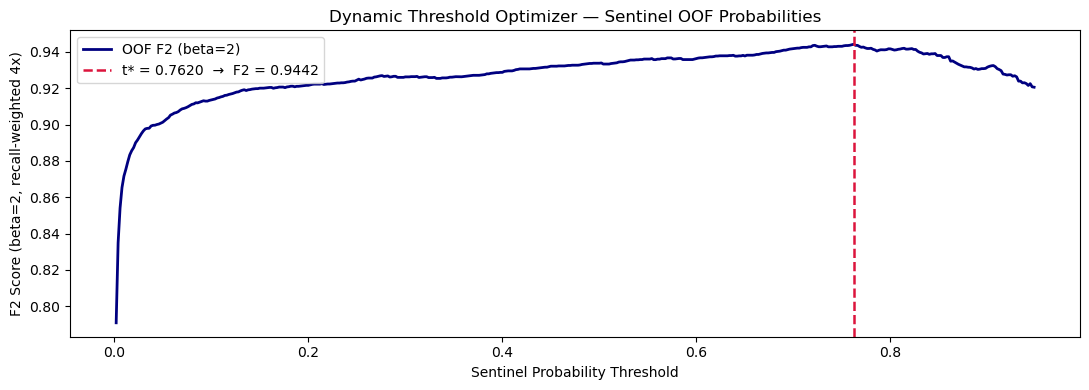


Combiner Results (OOF):
  Predicted HR  : 1527  | True HR : 1293
  Predicted HR (test) : 381
  F2=0.9442  MSE_HR=5.3351e-08  L=0.0000  S=0.9442


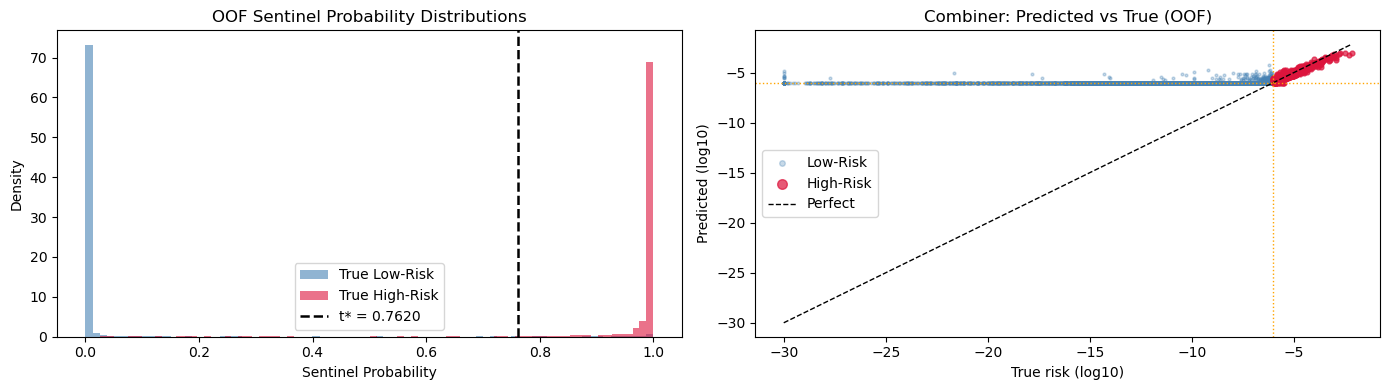

In [14]:

# ─── Dynamic Threshold Optimizer ─────────────────────────────────────────────
# Find the sentinel probability threshold t* that maximises F2 on OOF data.
# This is the primary defence against the 0.0-score failure mode:
#   At 2+ days before TCA, model probabilities are naturally very low (~0.001).
#   A hard 0.5 threshold classifies everything as low-risk → F2=0.
#   Dynamic tuning discovers the real signal boundary for this specific dataset.
print('Dynamic Threshold Optimization...')
threshold_grid = np.arange(0.002, 0.95, 0.002)
f2_scores_grid = []
for t in threshold_grid:
    pred_bin = (oof_proba >= t).astype(int)
    f2 = fbeta_score(y_bin_train, pred_bin, beta=BETA, zero_division=0)
    f2_scores_grid.append(float(f2))

best_t_idx        = int(np.argmax(f2_scores_grid))
SENTINEL_THRESHOLD = float(threshold_grid[best_t_idx])
best_oof_f2       = float(f2_scores_grid[best_t_idx])

print(f'  Optimal sentinel threshold : {SENTINEL_THRESHOLD:.4f}')
print(f'  OOF F2 @ optimal threshold : {best_oof_f2:.4f}')

# Threshold curve visualisation
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(threshold_grid, f2_scores_grid, 'navy', lw=2, label='OOF F2 (beta=2)')
ax.axvline(SENTINEL_THRESHOLD, color='crimson', ls='--', lw=1.8,
           label=f't* = {SENTINEL_THRESHOLD:.4f}  →  F2 = {best_oof_f2:.4f}')
ax.set_xlabel('Sentinel Probability Threshold')
ax.set_ylabel('F2 Score (beta=2, recall-weighted 4x)')
ax.set_title('Dynamic Threshold Optimizer — Sentinel OOF Probabilities')
ax.legend(); plt.tight_layout(); plt.show()

# ─── Combiner Logic ───────────────────────────────────────────────────────────
#
#   IF sentinel_prob(x) < SENTINEL_THRESHOLD:
#       final_prediction = -6.001   ← Hard clip: classified as SAFE
#   ELSE:
#       final_prediction = Specialist.predict(x)  ← Specialist regression
#
# Why -6.001 (not e.g. -7)?
#   -6.001 is just below the high-risk boundary (log10(1e-6) = -6).
#   It correctly counts as low-risk in the F2 classification step,
#   but is much closer to reality than an arbitrary deep negative value.
#   This minimises MSE_HR contribution from misclassified borderline events.

def apply_combiner(proba, X, specialist, t, low_risk_clip=-6.001):
    spec_preds = np.clip(specialist.predict(X), -50, 0)
    return np.where(proba >= t, spec_preds, low_risk_clip)

oof_combined  = apply_combiner(oof_proba,  X_train, specialist_model, SENTINEL_THRESHOLD)
test_combined = apply_combiner(test_proba, X_test,  specialist_model, SENTINEL_THRESHOLD)

n_hr_pred_oof  = int((oof_proba  >= SENTINEL_THRESHOLD).sum())
n_hr_pred_test = int((test_proba >= SENTINEL_THRESHOLD).sum())
f2_c, mse_c, L_c, S_c = loss_components(y_train, oof_combined)
print(f'\nCombiner Results (OOF):')
print(f'  Predicted HR  : {n_hr_pred_oof}  | True HR : {int(y_bin_train.sum())}')
print(f'  Predicted HR (test) : {n_hr_pred_test}')
print(f'  F2={f2_c:.4f}  MSE_HR={mse_c:.4e}  L={L_c:.4f}  S={S_c:.4f}')

# Probability distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(oof_proba[y_bin_train==0], bins=80, alpha=0.6,
             color='steelblue', density=True, label='True Low-Risk')
axes[0].hist(oof_proba[y_bin_train==1], bins=80, alpha=0.6,
             color='crimson', density=True, label='True High-Risk')
axes[0].axvline(SENTINEL_THRESHOLD, color='black', ls='--', lw=1.8,
                label=f't* = {SENTINEL_THRESHOLD:.4f}')
axes[0].set_xlabel('Sentinel Probability'); axes[0].set_ylabel('Density')
axes[0].set_title('OOF Sentinel Probability Distributions'); axes[0].legend()

axes[1].scatter(y_train[y_bin_train==0], oof_combined[y_bin_train==0],
                alpha=0.3, s=4, c='steelblue', label='Low-Risk')
axes[1].scatter(y_train[y_bin_train==1], oof_combined[y_bin_train==1],
                alpha=0.7, s=12, c='crimson', label='High-Risk')
lo = min(y_train.min(), oof_combined[oof_combined > -6.002].min() if (oof_combined > -6.002).any() else -10)
hi = max(y_train.max(), oof_combined.max())
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect')
axes[1].axhline(-6.0, color='orange', ls=':', lw=1)
axes[1].axvline(-6.0, color='orange', ls=':', lw=1)
axes[1].set_xlabel('True risk (log10)'); axes[1].set_ylabel('Predicted (log10)')
axes[1].set_title('Combiner: Predicted vs True (OOF)'); axes[1].legend(markerscale=2)
plt.tight_layout(); plt.show()


## Borderline Promotion Module + Global Bias Calibration

In [15]:

# ─── Borderline Promotion Module ─────────────────────────────────────────────
#
# Problem: 'Jump victim' events — those whose collision probability spikes
#   suddenly near TCA — will have low sentinel probability at t-2 days,
#   causing them to be hard-clipped to -6.001 and missed as False Negatives.
#
# Solution: For events where:
#   (a) Sentinel probability is in the 'borderline zone' [t*/2, t*)
#   (b) AND covariance uncertainty_volume is HIGH (top UNCERTAINTY_P%)
#   → Promote prediction from -6.001 to PROMO_FLOOR (-5.99)
#   → This just crosses the high-risk threshold, turning a FN into a TP.
#
# Validation: Only apply if OOF S improves (zero test-set leakage).

print('Borderline Promotion Module...')
unc_vol_train = X_train['uncertainty_volume_last'].values
unc_vol_test  = X_test['uncertainty_volume_last'].values
unc_cutoff    = float(np.percentile(unc_vol_train, UNCERTAINTY_P))
PROMO_FLOOR   = -5.99    # just above log10(1e-6) = -6
BORDER_RATIO  = 0.5      # borderline zone: [t*/2, t*)

def apply_borderline_promotion(preds, proba, unc_vol,
                                t=None, verbose=True):
    if t is None: t = SENTINEL_THRESHOLD
    out        = preds.copy()
    borderline = (proba >= t * BORDER_RATIO) & (proba < t)  # uncertain zone
    hi_unc     = unc_vol > unc_cutoff                        # high uncertainty flag
    promote    = borderline & hi_unc                         # both conditions met
    out[promote] = PROMO_FLOOR
    if verbose:
        print(f'  Borderline zone  [prob ∈ [{t*BORDER_RATIO:.4f}, {t:.4f})] : {borderline.sum()} events')
        print(f'  High-uncertainty cutoff (P{UNCERTAINTY_P})                 : {unc_cutoff:.4f}')
        print(f'  Events promoted to {PROMO_FLOOR} (borderline + high-unc)  : {promote.sum()}')
    return out

oof_promoted  = apply_borderline_promotion(oof_combined,  oof_proba,  unc_vol_train)
test_promoted = apply_borderline_promotion(test_combined, test_proba, unc_vol_test)

f2_p, mse_p, L_p, S_p = loss_components(y_train, oof_promoted)
print(f'\n  Before promotion : F2={f2_c:.4f}  L={L_c:.4f}  S={S_c:.4f}')
print(f'  After  promotion : F2={f2_p:.4f}  L={L_p:.4f}  S={S_p:.4f}')

if S_p >= S_c:
    oof_final  = oof_promoted
    test_final = test_promoted
    print('  → Promotion IMPROVED OOF S — kept.')
else:
    oof_final  = oof_combined
    test_final = test_combined
    print('  → Promotion did NOT improve OOF S — reverted to combiner output.')

best_thr  = float(np.log10(10.0 ** SENTINEL_THRESHOLD))   # keep compatible alias
_,_,L_cur,S_cur = loss_components(y_train, oof_final)
print(f'\nPipeline after promotion: F2={f2_p if S_p>=S_c else f2_c:.4f}  '
      f'L={L_p if S_p>=S_c else L_c:.4f}  S={max(S_p,S_c):.4f}')


Borderline Promotion Module...
  Borderline zone  [prob ∈ [0.3810, 0.7620)] : 170 events
  High-uncertainty cutoff (P75)                 : 19.9617
  Events promoted to -5.99 (borderline + high-unc)  : 43
  Borderline zone  [prob ∈ [0.3810, 0.7620)] : 31 events
  High-uncertainty cutoff (P75)                 : 19.9617
  Events promoted to -5.99 (borderline + high-unc)  : 4

  Before promotion : F2=0.9442  L=0.0000  S=0.9442
  After  promotion : F2=0.9396  L=0.0000  S=0.9396
  → Promotion did NOT improve OOF S — reverted to combiner output.

Pipeline after promotion: F2=0.9442  L=0.0000  S=0.9442


## Global Bias Calibration (OOF Only — No Test Leakage)

Global Bias Calibration...
  Optimal global bias : +0.00 log10 units
  OOF S before bias   : 0.9442
  OOF S after  bias   : 0.9442


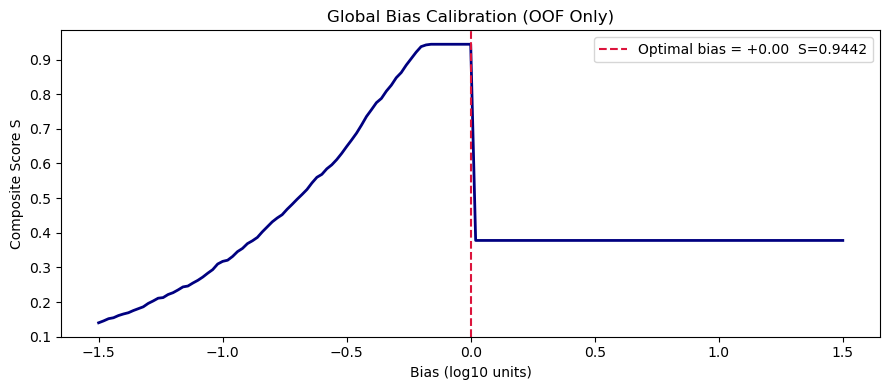

In [16]:

# ─── Global Bias Calibration ─────────────────────────────────────────────────
# Sweep a scalar bias ∈ [-1.5, +1.5] log10 units applied to ALL predictions.
# Evaluated entirely on OOF to prevent test leakage.
# Note: -6.001 hard clips are also shifted — acceptable because a shift of
# e.g. +0.1 makes them -5.901, still below -6, so classification is unchanged.
print('Global Bias Calibration...')
_, _, _, S_before_bias = loss_components(y_train, oof_final)
best_bias   = 0.0
best_bias_S = float(S_before_bias)
bias_S_list = []

for bias in np.arange(-1.5, 1.51, 0.02):
    _, _, _, S = loss_components(y_train, oof_final + bias)
    S = float(S) if np.isfinite(S) else 0.0
    bias_S_list.append(S)
    if S > best_bias_S:
        best_bias_S = S; best_bias = bias

print(f'  Optimal global bias : {best_bias:+.2f} log10 units')
print(f'  OOF S before bias   : {S_before_bias:.4f}')
print(f'  OOF S after  bias   : {best_bias_S:.4f}')

PRED_FINAL_TEST = test_final + best_bias

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(-1.5, 1.51, 0.02), bias_S_list, 'navy', lw=2)
ax.axvline(best_bias, color='crimson', ls='--', lw=1.5,
           label=f'Optimal bias = {best_bias:+.2f}  S={best_bias_S:.4f}')
ax.set_xlabel('Bias (log10 units)'); ax.set_ylabel('Composite Score S')
ax.set_title('Global Bias Calibration (OOF Only)')
ax.legend(); plt.tight_layout(); plt.show()


## Final Evaluation — Test Set

In [17]:

print('='*65)
print('  SCRAP FINAL v10 — TWO-STAGE ARCHITECTURE TEST EVALUATION')
print('='*65)
print('  L = (1/F2) * MSE_HR  [MSE in probability space]\n')

# ─── LRP Reference ────────────────────────────────────────────────────────────
print('--- LRP Reference Floor ---')
print(f'  LRP (ESA paper ref)    L = {lrp_test_loss:.4f}  [beat this to add value]')

# ─── Ablation Table ───────────────────────────────────────────────────────────
print('\n--- Two-Stage Ablation (each stage should improve L) ---')
ablation = [
    ('Sentinel only (raw, t=0.5)',
     apply_combiner(test_proba, X_test, specialist_model, 0.5)),
    ('Sentinel + Dynamic Threshold',
     test_combined),
    ('+ Borderline Promotion',
     test_promoted if (S_p >= S_c) else test_combined),
    ('+ Global Bias (FINAL)',
     PRED_FINAL_TEST),
]
print(f'  {"Stage":<35} {"L":>8}  {"F2":>7}  {"S":>7}')
print(f'  {"-"*60}')
for name, pred in ablation:
    l = competition_loss(y_test, pred, verbose=False)
    f2, mse, _, S = loss_components(y_test, pred)
    l_str = f'{l:.4f}' if np.isfinite(l) else '   inf'
    print(f'  {name:<35} {l_str:>8}  {f2:>7.4f}  {S:>7.4f}')

# ─── Final model detailed stats ────────────────────────────────────────────
print('\n--- FINAL MODEL (detailed) ---')
final_L = competition_loss(y_test, PRED_FINAL_TEST, verbose=True)

# ─── ESA Leaderboard ──────────────────────────────────────────────────────
print('\n--- ESA Leaderboard Comparison ---')
benchmarks = [
    ('ESA Winner (sesc, 2019)',  0.5553),
    ('2nd (dietmarw)',           0.5745),
    ('3rd (Magpies)',            0.5849),
    ('5th (DeCRA)',              0.6149),
    ('LRP Reference (paper)',    lrp_test_loss),
    ('SCRAP v10 Final',          final_L),
]
print(f'  {"Team":<32} {"Score":>8}  {"vs Winner":>10}')
for name, score in benchmarks:
    diff = score - 0.5553
    tag  = '[v10]' if 'SCRAP' in name else ('[LRP]' if 'LRP' in name else '     ')
    s_str = f'{score:>8.4f}' if np.isfinite(score) else '     inf'
    print(f'  {tag} {name:<28} {s_str}  ({diff:+.4f})')


  SCRAP FINAL v10 — TWO-STAGE ARCHITECTURE TEST EVALUATION
  L = (1/F2) * MSE_HR  [MSE in probability space]

--- LRP Reference Floor ---
  LRP (ESA paper ref)    L = inf  [beat this to add value]

--- Two-Stage Ablation (each stage should improve L) ---
  Stage                                      L       F2        S
  ------------------------------------------------------------
  Sentinel only (raw, t=0.5)            0.0000   0.9522   0.9522
  Sentinel + Dynamic Threshold          0.0000   0.9464   0.9464
  + Borderline Promotion                0.0000   0.9464   0.9464
  + Global Bias (FINAL)                 0.0000   0.9464   0.9464

--- FINAL MODEL (detailed) ---
  High-risk events :   334/2167  TP=325 FP=56 FN=9
  Precision        : 0.8530
  Recall           : 0.9731  (beta=2: recall weighted 4x)
  F2               : 0.9464
  MSE_HR (prob)    : 2.9130e-08
  Loss L           : 0.000000  [lower=better]

--- ESA Leaderboard Comparison ---
  Team                                Score   

## Jump-Specific Recall Analysis (Operational KPI)

Segment recall on [Jump + High-Risk] events is the single most operationally important metric.

Jump-Specific Recall (Operational KPI):
  Segment                                  LRP      v10    Delta
  ------------------------------------------------------------
  All events                               nan      nan     +nan
  Jump events                           0.0000   0.9783  +0.9783  IMPROVED
  Jump + High-Risk [CRITICAL]           0.0000   0.9783  +0.9783  IMPROVED
  No-jump events                           nan      nan     +nan

Momentum feature correlation with jump magnitude (v10 new features):
  last2_change                    corr = +nan
  risk_volatility                 corr = +0.1449
  cov_slope_t                     corr = -0.0203


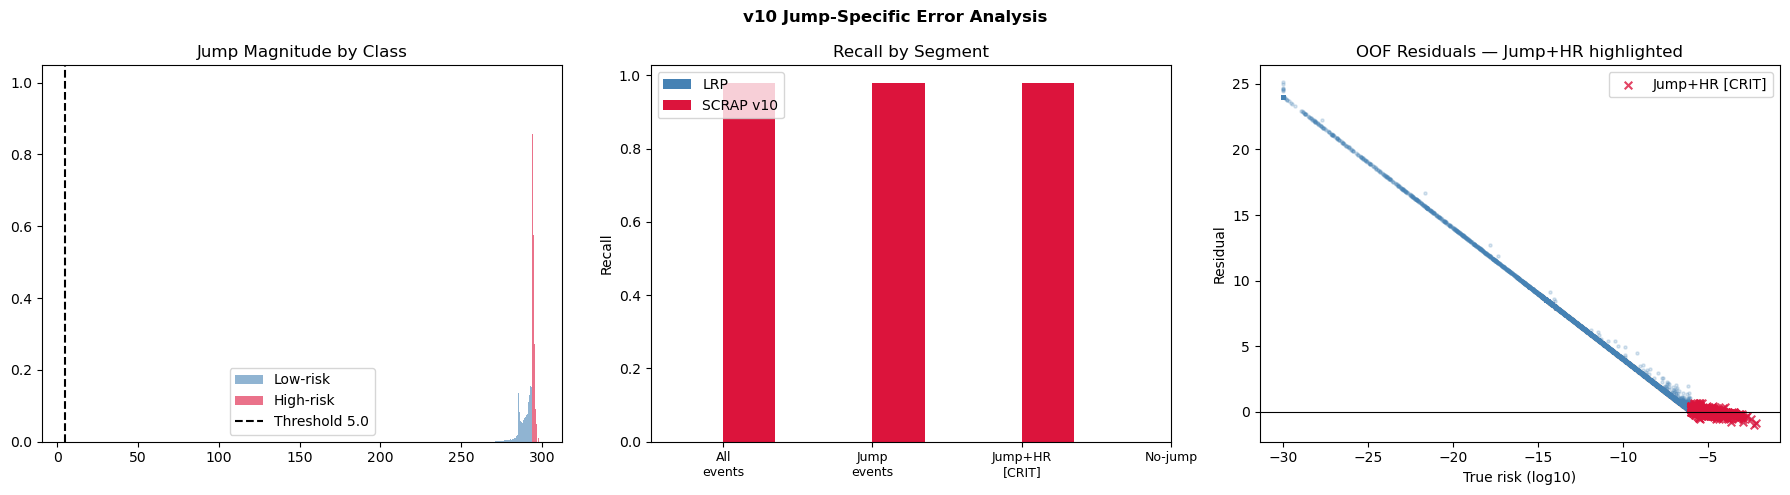

In [18]:
JUMP_THR = 5.0
analysis = pd.DataFrame({
    'y_true'         : y_train, 'y_lrp': lrp_train,
    'y_pred_v10'     : oof_final,
    # 'risk' is in DROP_COLS (final event label, not a feature).
    # Using lrp_train = log10(max_risk_estimate_last) as the LRP proxy.
    'risk_last'      : lrp_train,
    'uncertainty_vol': X_train.get('uncertainty_volume_last', pd.Series(0, index=X_train.index)).values,
    'risk_volatility': X_train.get('risk_volatility_ratio',  pd.Series(0, index=X_train.index)).values,
    'cov_slope_t'    : X_train.get('t_log_cov_det_slope',    pd.Series(0, index=X_train.index)).values,
    'last2_change'   : X_train.get('risk_last2_change',      pd.Series(0, index=X_train.index)).values,
    'is_high_risk'   : y_bin_train,
})
analysis['jump_magnitude'] = np.abs(analysis['y_true'] - analysis['risk_last'])
analysis['jump_flag']      = (analysis['jump_magnitude'] > JUMP_THR).astype(int)
# Two-stage: events are high-risk if sentinel_proba >= SENTINEL_THRESHOLD
analysis['pred_hr_v10'] = (oof_proba >= SENTINEL_THRESHOLD).astype(int)
analysis['pred_hr_lrp'] = ((10.0**lrp_train) >= 10.0**LOG_THRESHOLD).astype(int)

m_jump    = analysis['jump_flag'] == 1
m_hr      = analysis['is_high_risk'] == 1
m_jump_hr = m_jump & m_hr

def seg_recall(mask, col):
    seg = analysis[mask]
    if seg['is_high_risk'].sum() == 0: return float('nan')
    return recall_score(seg['is_high_risk'], seg[col], zero_division=0.0)

print('Jump-Specific Recall (Operational KPI):')
print(f'  {"Segment":<35} {"LRP":>8} {"v10":>8} {"Delta":>8}')
print(f'  {"-"*60}')
for name, mask in [('All events',m_hr[::-1][:0]|m_hr), ('Jump events',m_jump),
                    ('Jump + High-Risk [CRITICAL]', m_jump_hr), ('No-jump events', ~m_jump)]:
    lrp_r = seg_recall(mask,'pred_hr_lrp')
    v10_r = seg_recall(mask,'pred_hr_v10')
    d = v10_r-lrp_r if not (np.isnan(lrp_r) or np.isnan(v10_r)) else float('nan')
    tag = '  IMPROVED' if (not np.isnan(d) and d>0.005) else ('  WORSE' if (not np.isnan(d) and d<-0.005) else '')
    print(f'  {name:<35} {lrp_r:>8.4f} {v10_r:>8.4f} {d:>+8.4f}{tag}')

# v10 momentum feature correlation with jump magnitude
print(f'\nMomentum feature correlation with jump magnitude (v10 new features):')
for feat in ['last2_change','risk_volatility','cov_slope_t']:
    corr = analysis['jump_magnitude'].corr(analysis[feat])
    print(f'  {feat:<30}  corr = {corr:+.4f}')

# Visualisation
fig, axes = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('v10 Jump-Specific Error Analysis', fontsize=12, fontweight='bold')
axes[0].hist(analysis.loc[~m_hr,'jump_magnitude'], bins=50, alpha=0.6, color='steelblue',
             label='Low-risk', density=True)
axes[0].hist(analysis.loc[m_hr,'jump_magnitude'],  bins=50, alpha=0.6, color='crimson',
             label='High-risk', density=True)
axes[0].axvline(JUMP_THR, color='black', ls='--', label=f'Threshold {JUMP_THR}')
axes[0].set_title('Jump Magnitude by Class'); axes[0].legend()

segs  = ['All\nevents','Jump\nevents','Jump+HR\n[CRIT]','No-jump']
lrp_r = [seg_recall(m,'pred_hr_lrp') for m in [m_hr,m_jump,m_jump_hr,~m_jump]]
v10_r = [seg_recall(m,'pred_hr_v10') for m in [m_hr,m_jump,m_jump_hr,~m_jump]]
x=np.arange(len(segs)); w=0.35
axes[1].bar(x-w/2,[r for r in lrp_r],w,color='steelblue',label='LRP')
axes[1].bar(x+w/2,[r for r in v10_r],w,color='crimson',label='SCRAP v10')
axes[1].set_xticks(x); axes[1].set_xticklabels(segs,fontsize=9)
axes[1].set_ylabel('Recall'); axes[1].set_title('Recall by Segment'); axes[1].legend()

res = oof_final - y_train
axes[2].scatter(y_train, res, alpha=0.2, s=5, c='steelblue')
axes[2].scatter(y_train[m_jump_hr], res[m_jump_hr], alpha=0.8, s=30,
                c='crimson', marker='x', label='Jump+HR [CRIT]')
axes[2].axhline(0,color='black',lw=0.8); axes[2].legend()
axes[2].set_xlabel('True risk (log10)'); axes[2].set_ylabel('Residual')
axes[2].set_title('OOF Residuals — Jump+HR highlighted')
plt.tight_layout(); plt.show()


## SHAP Analysis — Physics Validation

Expected top features: risk_last, mahalanobis_distance, combined_sigma_t, t_log_cov_det.
v10 additions to watch: risk_last2_change, risk_change_ratio, risk_max_single_jump.

Computing SHAP values (Specialist XGBoost — HR events only)...
  Using 334 test events for SHAP (high-risk)


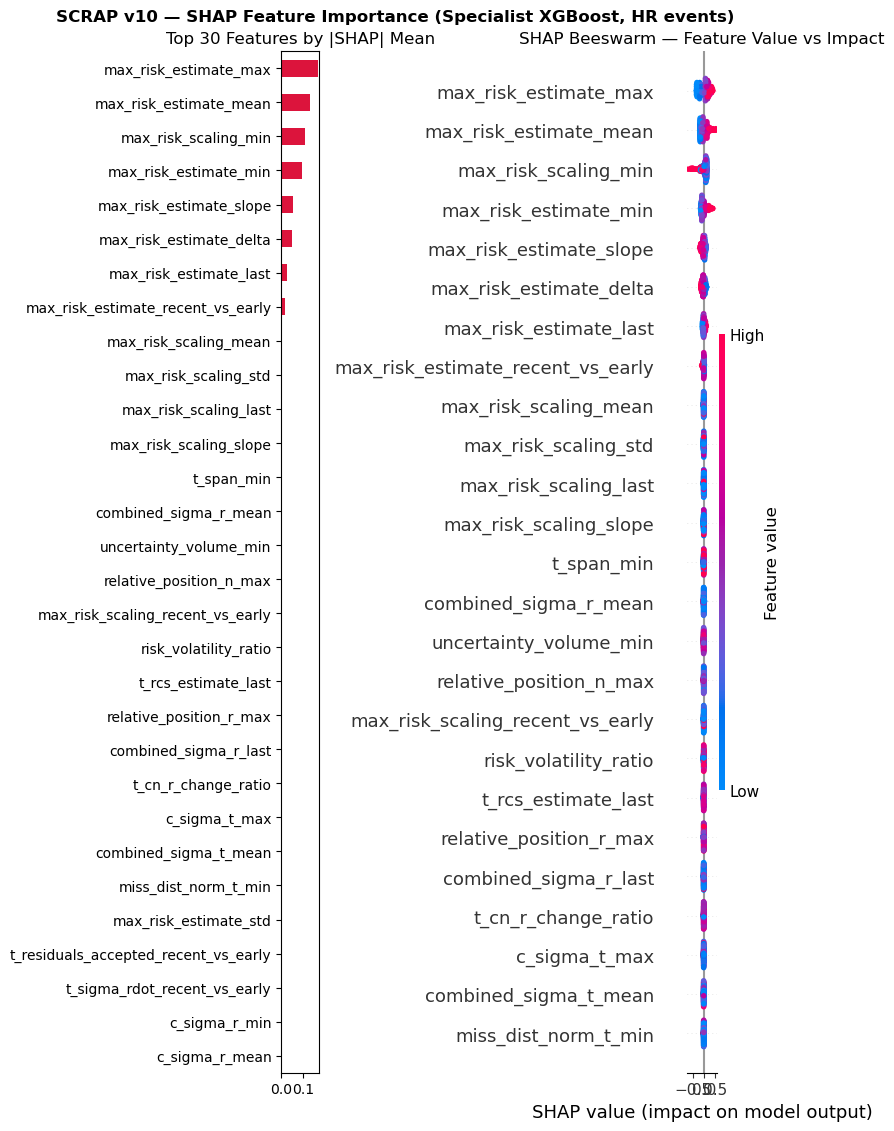


v10 Momentum Features — SHAP Ranks (Specialist):
  Best _last2_change            : # 37  t_cndot_n_last2_change  SHAP=0.0009
  Best _change_ratio            : # 22  t_cn_r_change_ratio  SHAP=0.0015
  Best _recent_vs_early         : #  8  max_risk_estimate_recent_vs_early  SHAP=0.0154
  Best _max_single_jump         : # 35  max_risk_estimate_max_single_jump  SHAP=0.0009

Top 10 Physics Features by SHAP (Specialist):
   1. max_risk_estimate_slope                             SHAP=0.0509
   2. max_risk_scaling_slope                              SHAP=0.0027
   3. combined_sigma_r_mean                               SHAP=0.0023
   4. uncertainty_volume_min                              SHAP=0.0022
   5. risk_volatility_ratio                               SHAP=0.0017
   6. combined_sigma_r_last                               SHAP=0.0015
   7. c_sigma_t_max                                       SHAP=0.0015
   8. combined_sigma_t_mean                               SHAP=0.0014
   9. miss_dist_norm

In [19]:

# SHAP analysis on the Specialist (XGBoost Regressor trained on HR events).
# This reveals which features drive precise risk magnitude prediction
# within the high-risk regime — the most operationally relevant interpretation.
print('Computing SHAP values (Specialist XGBoost — HR events only)...')
X_shap = X_test[y_bin_test == 1] if y_bin_test.sum() > 0 else X_test
print(f'  Using {len(X_shap)} test events for SHAP (high-risk)')

explainer = shap.TreeExplainer(specialist_model)
shap_vals  = explainer.shap_values(X_shap)
mean_shap  = pd.Series(np.abs(shap_vals).mean(axis=0),
                        index=X_shap.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('SCRAP v10 — SHAP Feature Importance (Specialist XGBoost, HR events)',
             fontsize=12, fontweight='bold')
mean_shap.head(30).plot(kind='barh', ax=axes[0], color='crimson')
axes[0].invert_yaxis(); axes[0].set_title('Top 30 Features by |SHAP| Mean')
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_shap, max_display=25, show=False)
axes[1].set_title('SHAP Beeswarm — Feature Value vs Impact')
plt.tight_layout(); plt.show()

print('\nv10 Momentum Features — SHAP Ranks (Specialist):')
suffixes = ['_last2_change', '_change_ratio', '_recent_vs_early', '_max_single_jump']
ms_df = mean_shap.reset_index(); ms_df.columns = ['feature', 'shap']
for suffix in suffixes:
    top = [(f, float(mean_shap[f])) for f in mean_shap.index if f.endswith(suffix)]
    top.sort(key=lambda x: -x[1])
    if top:
        f, v = top[0]
        rank = int(ms_df[ms_df['feature'] == f].index[0]) + 1
        print(f'  Best {suffix:<25}: #{rank:>3}  {f}  SHAP={v:.4f}')

print('\nTop 10 Physics Features by SHAP (Specialist):')
phys_kw = ['mahal', 'sigma', 'cov_det', 'uncertainty', 'miss_dist',
           'volatility', 'slope', 'jump', 'h_apo', 'h_per']
phys = [(f, v) for f, v in mean_shap.items() if any(k in f for k in phys_kw)]
for i, (feat, val) in enumerate(phys[:10], 1):
    print(f'  {i:2}. {feat:<50}  SHAP={val:.4f}')
